Imports, Data Understanding & Cleaning


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Understanding & Cleaning [cite: 53]
# Load the dataset (Ensure netflix_titles.csv is uploaded) [cite: 46]
df_netflix = pd.read_csv("/content/netflix_titles.csv.zip")

# Convert date_added to datetime [cite: 54]
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')

# Fill missing data in director, cast (and country just in case) [cite: 55]
df_netflix['director'] = df_netflix['director'].fillna('Unknown Director')
df_netflix['cast'] = df_netflix['cast'].fillna('Unknown Cast')
df_netflix['country'] = df_netflix['country'].fillna('Unknown Country')

print("Data loaded. Dates converted and missing values handled.")

Data loaded. Dates converted and missing values handled.


Feature Engineering (Time & Type Features)

In [2]:
# 2. Feature Engineering [cite: 58]

# Extract release_year (ensuring it is treated as an integer) [cite: 60]
df_netflix['release_year'] = df_netflix['release_year'].astype(int)

# Create release_decade feature [cite: 57]
df_netflix['release_decade'] = (df_netflix['release_year'] // 10) * 10

# Create is_movie feature [cite: 57]
df_netflix['is_movie'] = df_netflix['type'].apply(lambda x: 1 if x == 'Movie' else 0)

# Extract content_type from type column (Movie/TV Show) [cite: 61]
# Note: Since the 'type' column already contains "Movie" or "TV Show",
# we can just map it to a new column to fulfill the requirement.
df_netflix['content_type'] = df_netflix['type']

print("Time and content type features engineered.")

Time and content type features engineered.


Feature Engineering (Countries & Genres)

In [3]:
# Country popularity (top 5 countries) [cite: 62]
# Handling multi-label countries by extracting the first (primary) one listed
df_netflix['primary_country'] = df_netflix['country'].apply(lambda x: str(x).split(',')[0].strip())
top_5_countries = df_netflix['primary_country'].value_counts().head(5).index

# For the genres ('listed_in' column), we extract the primary genre to use in our heatmap later
df_netflix['primary_genre'] = df_netflix['listed_in'].apply(lambda x: str(x).split(',')[0].strip())

print("Top countries and primary genres extracted.")

Top countries and primary genres extracted.


EDA, Visualization & Insights

/tmp/ipykernel_17281/1218335873.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_genres.index, x=top_10_genres.values, palette='Reds_r')


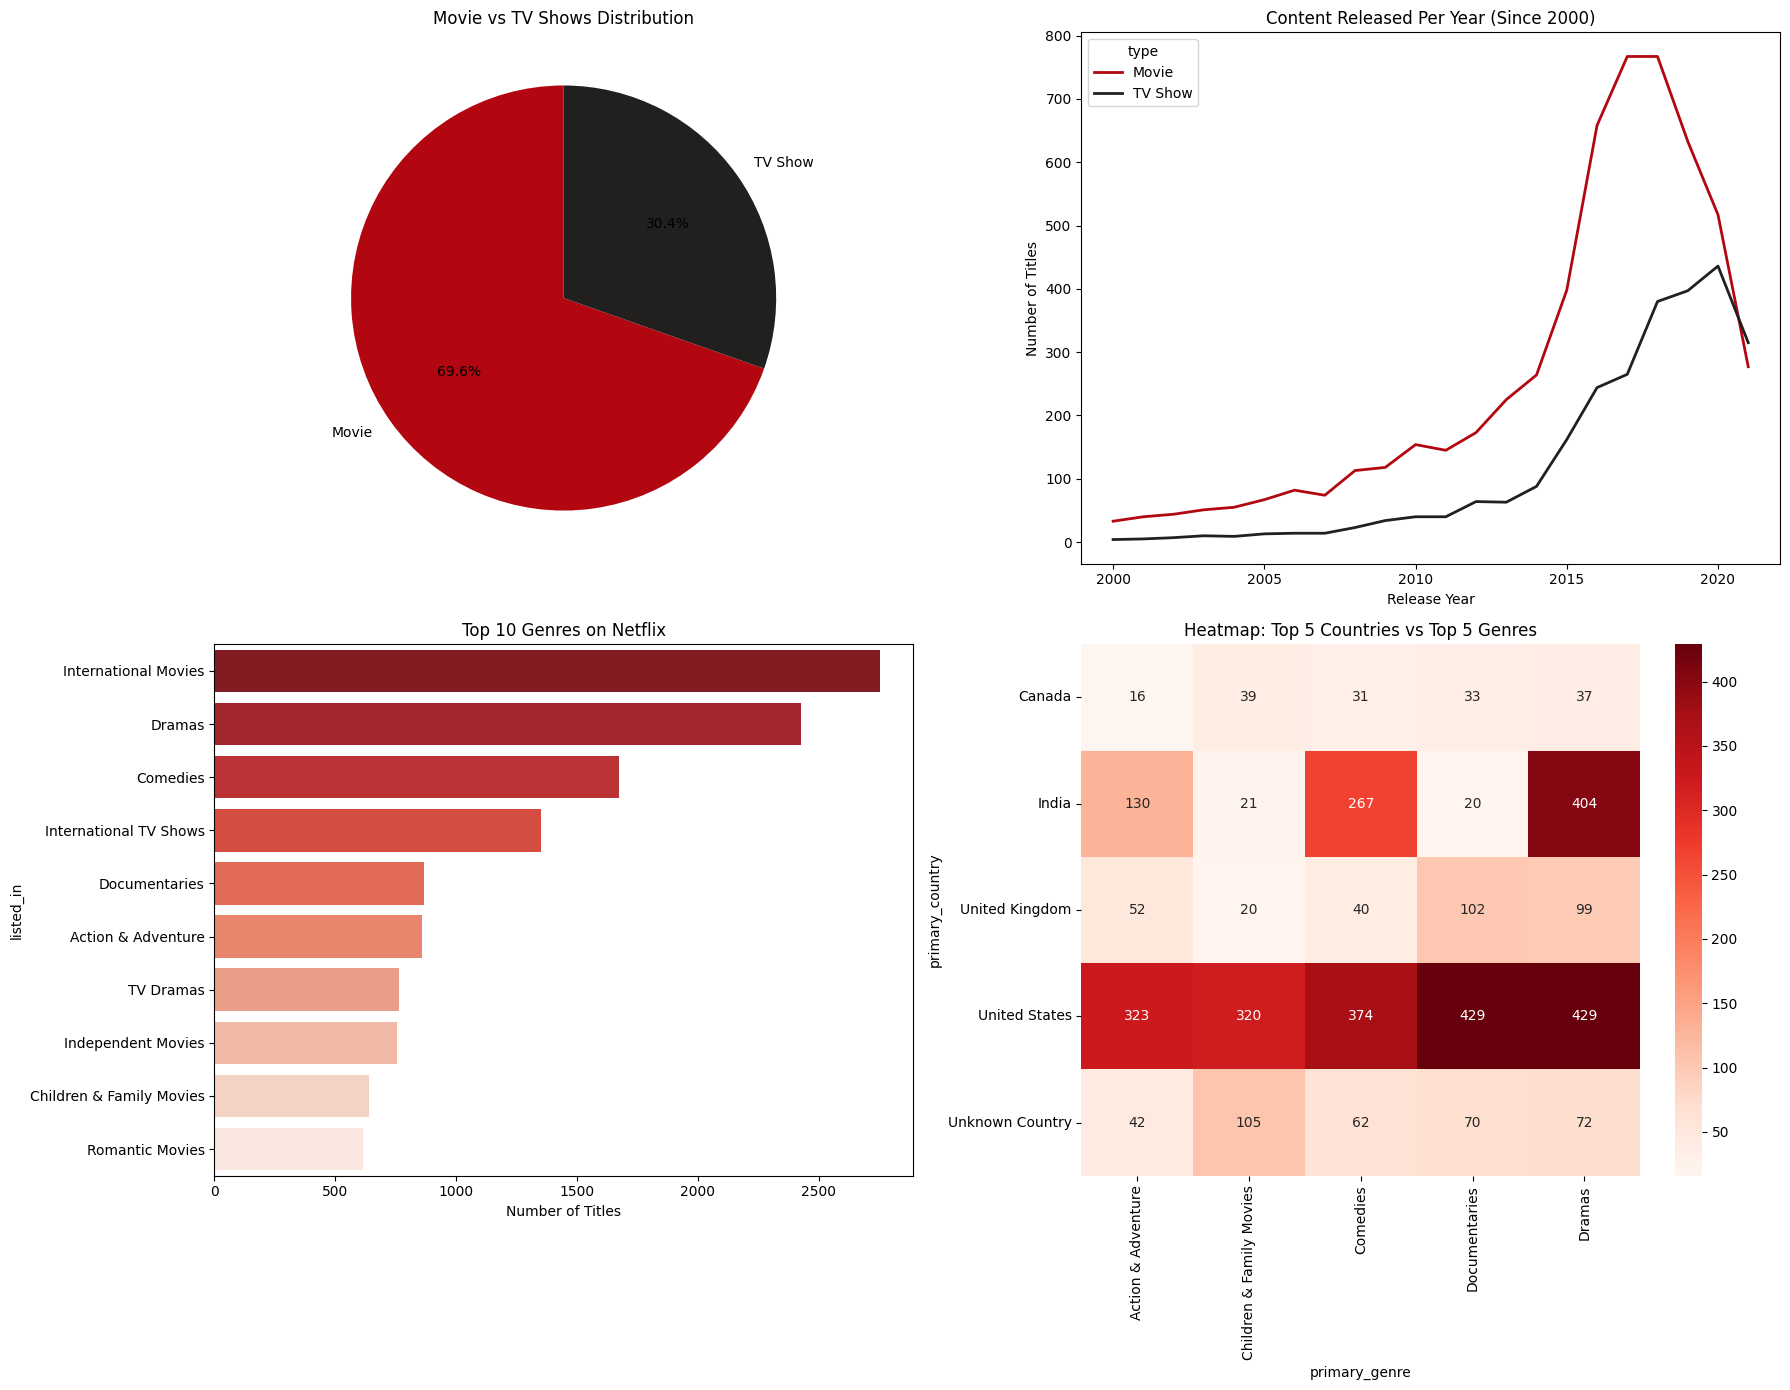

In [4]:
# 3. Visualization & Insights [cite: 63]
# Set up a large figure to hold all plots
fig = plt.figure(figsize=(18, 14))

# Pie chart: Movie vs TV shows [cite: 64]
plt.subplot(2, 2, 1)
type_counts = df_netflix['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#b20710', '#221f1f'])
plt.title('Movie vs TV Shows Distribution')

# Line plot: Content released per year [cite: 66]
plt.subplot(2, 2, 2)
yearly_counts = df_netflix[df_netflix['release_year'] >= 2000].groupby(['release_year', 'type']).size().unstack()
yearly_counts.plot(kind='line', ax=plt.gca(), color=['#b20710', '#221f1f'], linewidth=2)
plt.title('Content Released Per Year (Since 2000)')
plt.ylabel('Number of Titles')
plt.xlabel('Release Year')

# Barplot: Top 10 genres [cite: 68]
plt.subplot(2, 2, 3)
# Splitting and exploding the multi-label 'listed_in' column for an accurate total count
all_genres = df_netflix['listed_in'].str.split(', ').explode().str.strip()
top_10_genres = all_genres.value_counts().head(10)
sns.barplot(y=top_10_genres.index, x=top_10_genres.values, palette='Reds_r')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')

# Heatmap: Country vs content volume [cite: 69]
plt.subplot(2, 2, 4)
df_top_countries = df_netflix[df_netflix['primary_country'].isin(top_5_countries)]
# Get the top 5 genres specifically within these top 5 countries to keep the heatmap clean
top_5_genres_subset = df_top_countries['primary_genre'].value_counts().head(5).index
df_heatmap = df_top_countries[df_top_countries['primary_genre'].isin(top_5_genres_subset)]

country_genre_cross = pd.crosstab(df_heatmap['primary_country'], df_heatmap['primary_genre'])
sns.heatmap(country_genre_cross, annot=True, fmt='d', cmap='Reds')
plt.title('Heatmap: Top 5 Countries vs Top 5 Genres')

plt.tight_layout()
plt.show()